# Exercise 4: Regression I

## Task A1: Fit a regression model with `scikit-learn`

In [4]:
from sklearn.linear_model import LinearRegression

# One-hot encode the department variable
df_model = pd.get_dummies(df, columns=["department"], drop_first=True)
# drop_first effectively removes the HR department, setting it as the reference level

# Define X (features) and y (target)
# Note that we drop variables that should not be included in the model
X = df_model.drop(columns=["performance", "name", "employee_id", "role"])
y = df_model["performance"]

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Create a coefficient table
coef_df = pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})

# Print results
print(coef_df)
print("Intercept:", model.intercept_)

           variable  coefficient
0        experience     1.817213
1    training_hours     0.913459
2            salary     0.000382
3      remote_share    -0.936416
4         team_size     1.392150
5   manager_quality     5.821155
6     department_IT    13.929535
7  department_Sales    12.758165
Intercept: 45.630943483089595

> *Note: The `HR` department serves as the reference category.*



## Task A2: Interpret the coefficients

1.  Which variables have a positive association with performance?

The variables with a positive association with performance are:

- `experience`
- `training_hours`
- `salary`
- `team_size`
- `manager_quality`
- `department_IT`
- `department_Sales`

Their coefficients are all positive, which means that higher values of
these variables are associated with higher predicted performance,
holding the other variables constant.

1.  Which variables have a negative association with performance?

The variable with a negative association with performance is:

- `remote_share`

Its coefficient is negative (`-0.936`), which means that a higher share
of remote work is associated with slightly lower predicted performance,
holding the other variables constant.

1.  How would you interpret the coefficient of `remote_share`?

The coefficient of `remote_share` is about `-0.94`. Because
`remote_share` ranges from 0 to 1, this means:

- moving from fully on-site (`0`) to fully remote (`1`) is associated
  with a decrease of about `0.94` points in predicted performance,
  holding the other variables constant.

A smaller change is often easier to interpret in practice. For example:

- an increase of `0.10` in `remote_share` (10 percentage points more
  remote work) is associated with a decrease of about `0.094`
  performance points.

1.  Is the `remote_share` effect large or small in practical terms?

The effect appears to be small in practical terms.

Even a very large change in remote work share—from fully on-site to
fully remote—is associated with less than one point lower predicted
performance (`-0.94`). For a more realistic change of 10 percentage
points, the predicted difference is only about `-0.094` points.

Compared with other coefficients, especially `manager_quality` (`5.82`)
or the department coefficients (`about 13` to `14`), the `remote_share`
effect is relatively small.

1.  How should dummy variables such as `department_IT` or
    `department_Sales` be interpreted?

Dummy variables compare one category to the omitted reference category.

Here, `department_IT` and `department_Sales` show how those departments
differ from the reference department, which is the department that was
dropped during one-hot encoding. If `drop_first=True` was used and the
departments are ordered alphabetically, the reference category is `HR`.

This means:

- `department_IT = 13.93` suggests that employees in IT have, on
  average, about `13.93` points higher predicted performance than
  employees in the reference department, holding all other variables
  constant.
- `department_Sales = 12.76` suggests that employees in Sales have, on
  average, about `12.76` points higher predicted performance than
  employees in the reference department, again holding other variables
  constant.

These coefficients do not compare IT directly with Sales. Each is
compared to the reference department.



# Part B — Regression tables with `statsmodels` <a id="statsmodels"></a>

## Task B1: Estimate the same model with `statsmodels`

In [6]:
import statsmodels.formula.api as smf

# Fit the regression model using a formula
model_sm = smf.ols(
    formula="performance ~ experience + training_hours + salary + remote_share + team_size + manager_quality + C(department)",
    data=df
).fit()

# Print the regression table
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            performance   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     768.8
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:42:44   Log-Likelihood:                -5207.8
No. Observations:                1400   AIC:                         1.043e+04
Df Residuals:                    1391   BIC:                         1.048e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 45



## Task B2: Interpret the regression table

### Questions:

1.  **Compare coefficients** Are the coefficient estimates (e.g., for
    `remote_share`) similar to those from `scikit-learn`?

Yes, the coefficients are the same (up to rounding). Both libraries
estimate the same model on the same data, so we expect identical
results.

1.  **Understanding statistical significance** Which variables are
    statistically significant based on the p-values? How does this
    additional information change (or not change) your interpretation
    from Part A?

All variables except `remote_share` are statistically significant (p \<
0.05).

This adds to Part A: although `remote_share` has a negative coefficient,
it is not statistically reliable.

1.  **Interpreting `remote_share` more formally** What do the p-value
    and confidence interval suggest about the reliability of the
    `remote_share` effect?

The p-value (0.449) is high and the confidence interval includes 0.

This suggests that the effect of `remote_share` is uncertain and not
statistically significant.

1.  **Model fit and explanatory power** What do R² and adjusted R² tell
    you about how well the model explains performance? Why should we be
    cautious when interpreting these values?

R² ≈ 0.82 means the model explains a large share of variation in
performance.

However, a high R² does not guarantee that the model is correct or that
effects are causal.

1.  **Comparing workflows: `scikit-learn` vs. `statsmodels`** Reflect on
    how the model was specified in both parts:

    - How did you define variables and transformations in
      `scikit-learn`?
    - How does the **formula interface** in `statsmodels` simplify (or
      change) this process?
    - What are the advantages of using a formula like
      `performance ~ remote_share + ...`?

In `scikit-learn`, we manually prepared data (e.g., dummy variables,
X/y).

In `statsmodels`, the formula (`performance ~ ... + C(department)`)
simplifies this.

The formula approach is more readable and better suited for
interpretation.



# Part C — Regression diagnostics <a id="diagnostics"></a>

## Task C1: Residual plot

Create a simple residual plot for the fitted `scikit-learn` model from
part A.

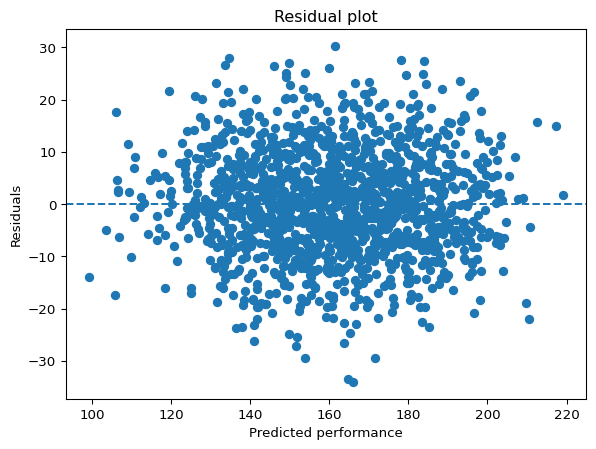

In [8]:
import matplotlib.pyplot as plt

residuals = y - model.predict(X)
plt.scatter(model.predict(X), residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted performance")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

Questions:

1.  Do the residuals look roughly random?

Yes, the residuals appear to be randomly scattered around zero.

This suggests that the linear model is a reasonable approximation of the
relationship in the data.

1.  Do you see patterns that may indicate model problems?

No clear patterns are visible (e.g., no curvature or systematic
structure).

This indicates that there are no obvious signs of model misspecification
based on this plot.

1.  What would a clear funnel shape suggest?

A funnel shape would suggest **heteroscedasticity**, meaning that the
variance of the residuals changes with the predicted values.

This would violate a key regression assumption (constant variance) and
could make standard errors and statistical tests unreliable.



# Part D — Subgroup analysis: does one model fit all departments? <a id="subgroup-analysis"></a>

## Task D1: Department-specific regressions

Estimate separate regressions for `Sales`, `IT`, and `HR`.

In [10]:
import statsmodels.api as sm

results = {}

for dept in df["department"].unique():
    # Subset data for one department
    df_sub = df[df["department"] == dept].copy()

    # Define X and y
    X_sub = df_sub[
        ["experience", "training_hours", "salary", "remote_share", "team_size", "manager_quality"]
    ]
    y_sub = df_sub["performance"]

    # Add constant and fit OLS model
    X_sub = sm.add_constant(X_sub)
    model_sub = sm.OLS(y_sub, X_sub).fit()

    # Store result
    results[dept] = model_sub

    print(f"\n=== Regression results for {dept} ===")
    print(model_sub.summary())


=== Regression results for Sales ===
                            OLS Regression Results                            
Dep. Variable:            performance   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     392.3
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          5.90e-198
Time:                        13:42:45   Log-Likelihood:                -2099.4
No. Observations:                 573   AIC:                             4213.
Df Residuals:                     566   BIC:                             4243.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
cons



## Task D2: Compare the subgroup models

Use the results to answer the following questions.

1.  Do the coefficients differ across departments?

Yes, the coefficients differ across departments. While most variables
(e.g., experience, training_hours, salary, team_size, manager_quality)
are positively associated with performance in all departments, the
magnitude of these effects varies.

For example, experience has a stronger effect in Sales than in HR, and
manager_quality is much more influential in IT than in the other
departments. In contrast, training_hours shows a very similar effect
across all departments.

This indicates that the strength of relationships is not constant across
departments.

1.  Is `remote_share` associated with performance in the same way in
    every department?

No, the association differs across departments.

In Sales, remote_share has a negative but not statistically significant
effect. In HR, it has a negative and statistically significant effect,
suggesting that more remote work is associated with lower performance.
In contrast, in IT, the effect is positive and statistically
significant.

This shows that remote work impacts performance differently depending on
the department.

1.  Does `manager_quality` seem equally important in all departments?

No, although manager_quality is positively and significantly associated
with performance in all departments, its importance varies.

The effect is strongest in IT, where the coefficient is substantially
larger than in Sales and HR. This suggests that high-quality management
may be particularly critical in IT compared to other departments.

1.  What does this tell us about heterogeneity in company data?

The results indicate that the data are heterogeneous across departments.
The same variables do not have identical effects everywhere, and some
relationships (e.g., remote_share) even change direction.

This suggests that departments differ in their work structures, tasks,
and coordination needs, leading to different performance drivers.

1.  Why might a single model be too simplistic?

A single model assumes that the effects of all variables are the same
across departments (apart from intercept differences when using
dummies).

However, the subgroup results show that some effects vary in magnitude
or even direction. A single model would therefore mask these differences
and potentially lead to misleading conclusions.

Using subgroup models or interaction terms can better capture these
variations.

> **Key idea**
>
> If relationships differ strongly between groups, a single regression
> model can hide important structure.

# Part E — Deployment <a id="deployment"></a>

Saving and loading a model is useful in practice, but it is not the main
conceptual focus of this notebook.

Here, it is included as an optional extension after you have already
worked through model estimation, interpretation, diagnostics, and
subgroup analysis.

## Task E1 (optional): Save a fitted model

In [12]:
import joblib

# Save the fitted sklearn model
joblib.dump(model, "data/employee_performance_model.joblib")

['data/employee_performance_model.joblib']



## Task E2 (optional): Load the model and predict a new case

In [14]:
import joblib
import pandas as pd

# Load the saved model
loaded_model = joblib.load("data/employee_performance_model.joblib")

# Create a new employee record (must match training data structure)
new_employee = pd.DataFrame([
    {
        "experience": 8,
        "training_hours": 45,
        "salary": 56000,
        "remote_share": 0.4,
        "team_size": 7,
        "manager_quality": 4,
        "department_IT": 1,
        "department_Sales": 0,
    }
])

# Generate prediction
prediction = loaded_model.predict(new_employee)
print(prediction)

[169.22919069]

## Task E3: Reflect on practical and organizational considerations

**Questions:**

1.  What practical challenges might arise when using this model to
    support decisions about employees?

- The model may rely on incomplete or imperfect data (e.g., missing
  relevant factors like motivation or task complexity).
- Input data for new predictions must be prepared in exactly the same
  way (same variables, same encoding).
- The model may not generalize well if the company changes (e.g., new
  work practices or policies).
- Interpretation requires care—managers may misread coefficients as
  causal effects.

1.  What risks could emerge if the model is used without careful
    interpretation or oversight?

- Decisions could be based on misleading relationships (e.g.,
  interpreting correlation as causation).
- The model could unintentionally disadvantage certain groups (e.g.,
  departments or work styles).
- Overreliance on the model could reduce human judgment and
  context-sensitive decision-making.
- Employees may lose trust if decisions appear opaque or unfair.

1.  What steps and safeguards would be important to ensure that the
    model is used **fairly, transparently, and responsibly**, taking
    into account legal and organizational requirements (e.g., employee
    representation, data protection)?

- Ensure **legal compliance from the outset**, especially with data
  protection regulations (e.g., GDPR) and rules governing employee data
  and monitoring.
- Involve **employee representatives (e.g., works councils)** early in
  the process, as the use of such models for employee-related decisions
  may require formal involvement and approval.
- Define clearly **how the model will be used** (e.g., decision support
  vs. automated decisions) and ensure this aligns with legal and
  organizational guidelines.
- Ensure transparency: document how the model works, what data is used,
  and how results should be interpreted.
- Communicate openly with employees to maintain trust and clarify the
  purpose and limits of the model.
- Check for potential bias or unfair effects across groups (e.g.,
  departments) and address them if necessary.
- Validate the model regularly and monitor whether it remains
  appropriate as conditions change.

Overall, responsible use requires aligning technical implementation with
legal requirements, organizational processes, and ethical
considerations.